<a href="https://colab.research.google.com/github/Asaad972/CollabFirstNoteBook/blob/main/Tut10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Java
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Download Apache Spark
!wget -q https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz

# Unzip the file
!tar xf spark-3.4.1-bin-hadoop3.tgz

# Install findspark to connect Python with Spark
!pip install -q findspark

In [2]:
import os
import findspark

# Set environment variables
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.4.1-bin-hadoop3"

# Initialize findspark
findspark.init()

# Create Spark Session
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Big Data Tutorial").getOrCreate()
print("Spark Session Created Successfully!")

Spark Session Created Successfully!


In [3]:
# Define data
data = [("Tal", 120), ("Uri", 90), ("Dina", 150)]
columns = ["name", "price"]

# Create DataFrame
df = spark.createDataFrame(data, columns)

# Show data
print("Original Data:")
df.show()

# Filter where price > 100
print("Filtered Data (Price > 100):")
df.filter(df["price"] > 100).show()

Original Data:
+----+-----+
|name|price|
+----+-----+
| Tal|  120|
| Uri|   90|
|Dina|  150|
+----+-----+

Filtered Data (Price > 100):
+----+-----+
|name|price|
+----+-----+
| Tal|  120|
|Dina|  150|
+----+-----+



In [4]:
import kagglehub

# Download the Amazon dataset
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")
print("Path to dataset:", path)

# Find the CSV file automatically
import glob
csv_file = glob.glob(f"{path}/*.csv")[0]

# Load into Spark
df_amazon = spark.read.csv(csv_file, header=True, inferSchema=True)

# 1. Filter positive reviews (rating >= 4)
print("Example of Positive Reviews:")
df_amazon.filter(df_amazon["`reviews.rating`"] >= 4).select("`reviews.text`", "`reviews.rating`").show(3, truncate=50)

# 2. Count reviews per rating
print("Count by Rating:")
df_amazon.groupBy("`reviews.rating`").count().orderBy("count", ascending=False).show()

Using Colab cache for faster access to the 'consumer-reviews-of-amazon-products' dataset.
Path to dataset: /kaggle/input/consumer-reviews-of-amazon-products
Example of Positive Reviews:
+--------------------------------------------------+--------------+
|                                      reviews.text|reviews.rating|
+--------------------------------------------------+--------------+
|https://redsky.target.com/groot-domain-api/v1/r...|             4|
|http://reviews.bestbuy.com/3545/5442403/reviews...|             9|
|https://redsky.target.com/groot-domain-api/v1/r...|            97|
+--------------------------------------------------+--------------+
only showing top 3 rows

Count by Rating:
+--------------+-----+
|reviews.rating|count|
+--------------+-----+
|             5| 2691|
|             4|  877|
|          TRUE|  860|
|             3|  161|
|          null|  154|
|             0|  108|
|             1|   60|
|             2|   47|
|         FALSE|   35|
|            97|    

In [5]:
# Create RDD (Resilient Distributed Dataset)
rdd = spark.sparkContext.parallelize([("apple", 1), ("banana", 1), ("apple", 1)])

# ReduceByKey to sum counts
# Map step is implicit here as we already have (key, value) pairs
result = rdd.reduceByKey(lambda a, b: a + b)

# Collect and print
print("Fruit Counts:", result.collect())

Fruit Counts: [('apple', 2), ('banana', 1)]


In [6]:
# Simulated Logs
logs = [
    "192.168.1.10 - [10/May/2025:13:00] GET /index.html",
    "172.16.0.5 - - [10/May/2025:13:01] GET /contact.html",
    "192.168.1.10 - [10/May/2025:13:02] GET /products.html",
    "10.0.0.1 - - [10/May/2025:13:02] GET /index.html",
    "192.168.1.10 - [10/May/2025:13:03] GET /about.html"
]

rdd_logs = spark.sparkContext.parallelize(logs)

# MAP: Extract IP and assign count of 1 -> (IP, 1)
ip_counts = rdd_logs.map(lambda line: (line.split()[0], 1))

# REDUCE: Sum counts by IP
result_ips = ip_counts.reduceByKey(lambda a, b: a + b)

# Print results
print("IP Visit Counts:")
for ip, count in result_ips.collect():
    print(f"{ip}: {count}")

IP Visit Counts:
172.16.0.5: 1
192.168.1.10: 3
10.0.0.1: 1


In [7]:
from pyspark.sql.functions import col

# Select review text and remove nulls
df_clean = df_amazon.select(col('`reviews.text`').alias("review")).filter(col("review").isNotNull())

# Create RDD from the text column
rdd_text = df_clean.select("review").rdd.map(lambda row: row["review"])

# MapReduce Chain:
# 1. flatMap: Split each review into individual words
# 2. map: Assign (word, 1) to each word
# 3. reduceByKey: Sum the counts
word_counts = rdd_text.flatMap(lambda line: line.lower().split()) \
                      .map(lambda word: (word, 1)) \
                      .reduceByKey(lambda a, b: a + b)

# Show top 10 most frequent words
print("Top 10 Words:")
# We sort locally for display purposes
print(word_counts.takeOrdered(10, key=lambda x: -x[1]))

Top 10 Words:
[('the', 4992), ('to', 3761), ('and', 3711), ('i', 3265), ('it', 2753), ('for', 2598), ('a', 2482), ('is', 2226), ('my', 2124), ('this', 1782)]


File Loaded. Columns found:
root
 |-- id: string (nullable = true)
 |-- value: string (nullable = true)
 |-- feed_id: string (nullable = true)
 |-- created_at: string (nullable = true)
 |-- lat: string (nullable = true)
 |-- lon: string (nullable = true)
 |-- ele: integer (nullable = true)


Analyzing columns: ['ele']

--- MapReduce Analysis (Min/Max) ---
Parameter: ele | Min: 3255183 | Max: 3255183


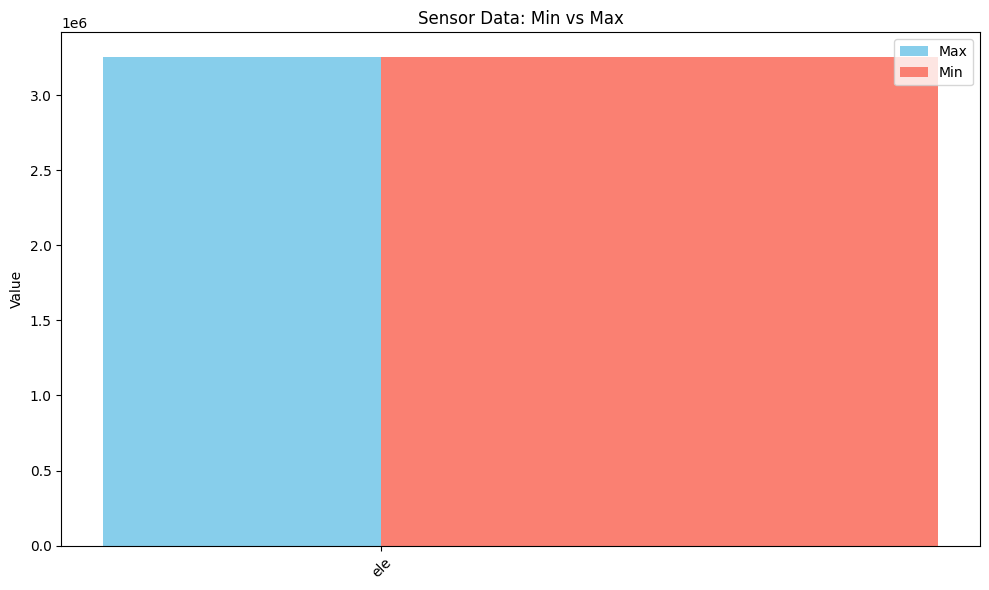

In [10]:
import os
import matplotlib.pyplot as plt
from pyspark.sql.types import IntegerType, DoubleType, FloatType
from pyspark.sql.functions import col

# 1. Load your specific file
filename = "csv_json-20251229-2143.csv"

if os.path.exists(filename):
    df_exercise = spark.read.csv(filename, header=True, inferSchema=True)

    print("File Loaded. Columns found:")
    df_exercise.printSchema()

    # 2. Identify numeric columns
    numeric_cols = [f.name for f in df_exercise.schema.fields
                    if isinstance(df_exercise.schema[f.name].dataType, (IntegerType, DoubleType, FloatType))]

    results = {}

    print(f"\nAnalyzing columns: {numeric_cols}")
    print("\n--- MapReduce Analysis (Min/Max) ---")

    for col_name in numeric_cols:
        # --- FIX IS HERE ---
        # We filter out NULL values first so the math doesn't break
        clean_df = df_exercise.select(col_name).filter(col(col_name).isNotNull())

        # MAP Step
        rdd_col = clean_df.rdd.map(lambda row: (col_name, row[0]))

        # Check if RDD is empty after filtering
        if not rdd_col.isEmpty():
            # REDUCE Step (Max)
            max_val = rdd_col.reduceByKey(lambda a, b: a if a > b else b).collect()

            # REDUCE Step (Min)
            min_val = rdd_col.reduceByKey(lambda a, b: a if a < b else b).collect()

            if max_val and min_val:
                val_max = max_val[0][1]
                val_min = min_val[0][1]
                results[col_name] = (val_min, val_max)
                print(f"Parameter: {col_name} | Min: {val_min} | Max: {val_max}")
        else:
            print(f"Skipping {col_name}: All values are null.")

    # 3. Graph Plotting
    if results:
        names = list(results.keys())
        mins = [results[k][0] for k in names]
        maxs = [results[k][1] for k in names]

        x = range(len(names))
        plt.figure(figsize=(10, 6))
        plt.bar(x, maxs, width=0.4, label='Max', color='skyblue', align='center')
        plt.bar(x, mins, width=0.4, label='Min', color='salmon', align='edge')
        plt.xticks(x, names, rotation=45)
        plt.ylabel("Value")
        plt.title("Sensor Data: Min vs Max")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric data found to plot.")

else:
    print(f"Error: File '{filename}' not found. Please upload it to the Colab Files section.")